In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd;
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/personal_transactions_dashboard_ready.xlsx')

In [8]:
df.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01


In [9]:
print(df.shape)
print(df.columns)

df.info()

(806, 7)
Index(['Date', 'Description', 'Amount', 'Transaction Type', 'Category',
       'Account Name', 'Month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account Name      806 non-null    object        
 6   Month             806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 44.2+ KB


In [10]:
df.describe()

,Date,Amount
count,806,806.000000
mean,2018-11-12 00:00:00.000000256,273.391489
min,2018-01-01 00:00:00,1.750000
25%,2018-06-03 06:00:00,15.687500
50%,2018-11-11 00:00:00,37.480000
75%,2019-04-18 18:00:00,117.680000
max,2019-09-30 00:00:00,9200.000000
std,NaN,667.630374


In [11]:
print(df['Transaction Type'].value_counts())

Transaction Type
debit     688
credit    118
Name: count, dtype: int64


In [12]:
category_expense = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

print(category_expense)

Category
Paycheck                  93750.00
Credit Card Payment       63561.12
Mortgage & Rent           24754.50
Home Improvement          19092.87
Groceries                  2795.21
Utilities                  2776.00
Restaurants                2613.02
Shopping                   1973.24
Gas & Fuel                 1715.17
Mobile Phone               1680.40
Internet                   1570.88
Auto Insurance             1350.00
Electronics & Software      719.00
Alcohol & Bars              539.13
Haircut                     378.00
Fast Food                   330.63
Music                       224.49
Movies & Dvds               222.19
Coffee Shops                115.54
Television                  104.78
Food & Dining                77.75
Entertainment                 9.62
Name: Amount, dtype: float64


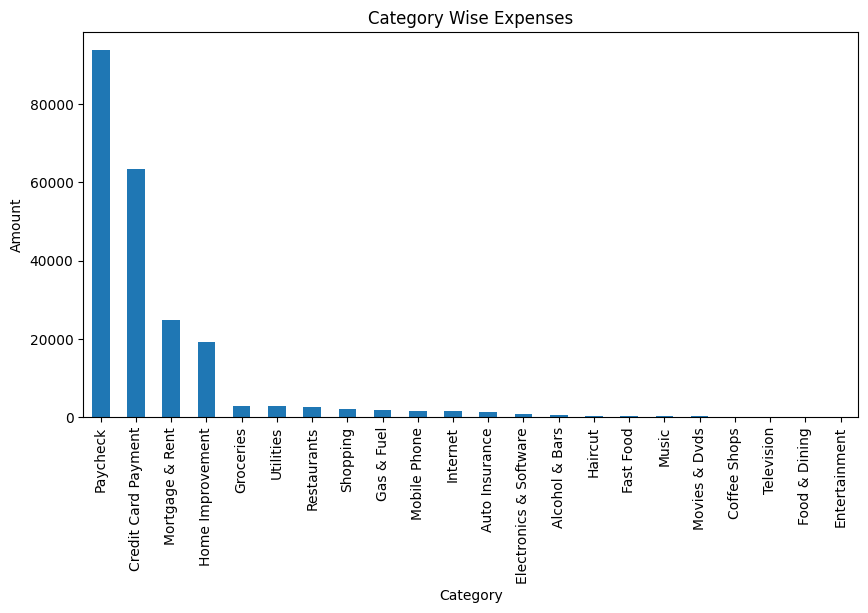

In [13]:
import matplotlib.pyplot as plt

category_expense.plot(kind='bar', figsize=(10,5))

plt.title('Category Wise Expenses')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.show()

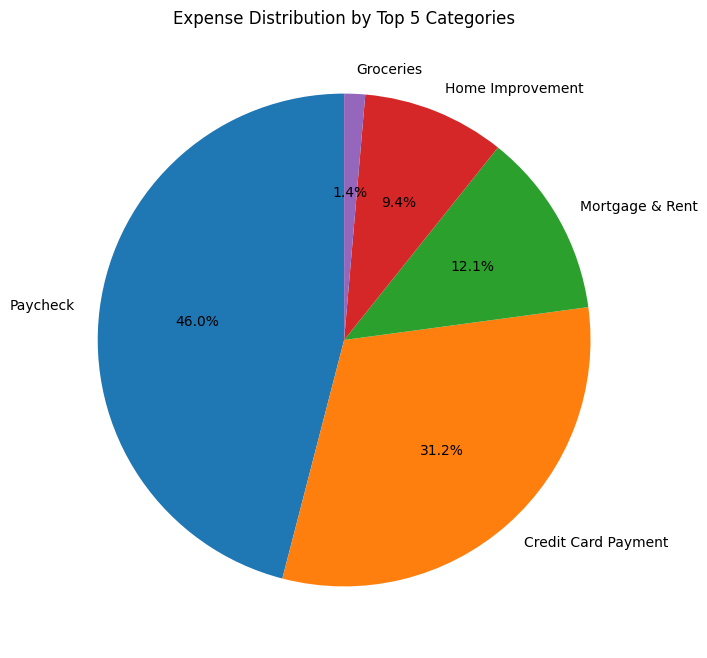

In [17]:
category_expense = df.groupby('Category')['Amount'].sum()

top_categories = category_expense.nlargest(5)

plt.figure(figsize=(8,8))
plt.pie(
    top_categories,
    labels=top_categories.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Expense Distribution by Top 5 Categories')
plt.show()

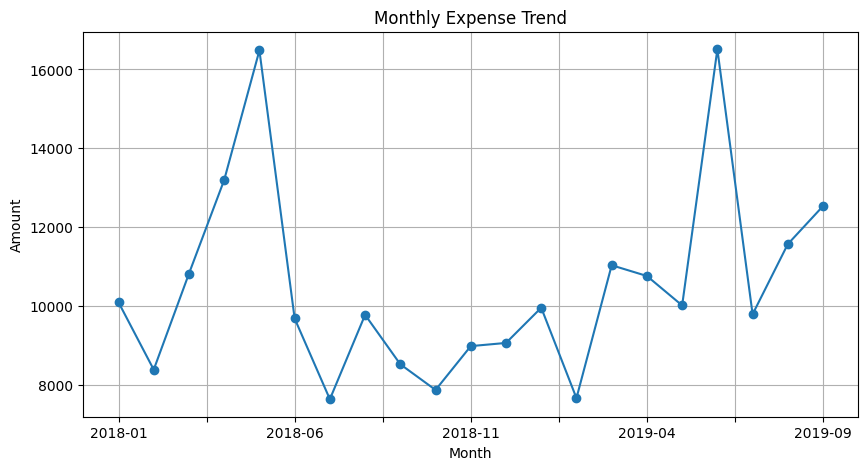

In [15]:
monthly_expense = df.groupby('Month')['Amount'].sum()

monthly_expense.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Monthly Expense Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.grid(True)

plt.show()

In [16]:
print("Total Transactions :", len(df))
print("Total Amount :", df['Amount'].sum())
print("Average Amount :", df['Amount'].mean())
print("Highest Transaction :", df['Amount'].max())

Total Transactions : 806
Total Amount : 220353.54
Average Amount : 273.3914888337469
Highest Transaction : 9200.0
